In [46]:
import gymnasium as gym

import numpy as np
import matplotlib.pyplot as plt

import mujoco

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from PIL import Image

import sys
sys.path.insert(0, "..") #"../custom_gym_env"

%load_ext autoreload
%autoreload 2

from mujoco_gym import PickPlacePandaEnvController

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Snapshots

array([5.00613730e-01, 8.93760818e-04, 1.62171906e-01, 1.79993502e+02,
       8.21755769e-01, 1.39324621e-03, 0.00000000e+00])

array([ 5.00756073e-01, -2.97759982e-03,  1.62745009e-01,  1.79998833e+02,
        8.22132696e-01,  1.65311710e-03,  0.00000000e+00])

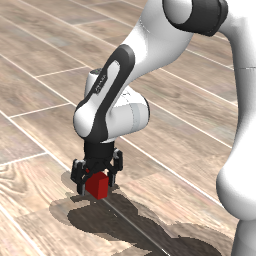

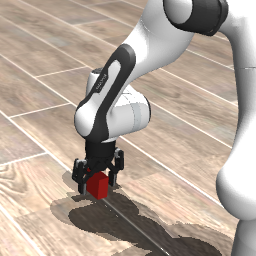

In [54]:
capture = np.load("../outputs/capture_1787411550.0767727.npz")
capture2 = np.load("../outputs/capture_1769832812.9509695.npz")

capture['state']
capture2['state']

Image.fromarray(capture['img']).crop((320, 140, 576, 396))
Image.fromarray(capture2['img']).crop((320, 140, 576, 396))

In [57]:
env = PickPlacePandaEnvController(
    "C:\\Users\\gdev\\Documents\\CS\\DL\\projects\\Robotics\\custom_gym_env\\robots/franka_emika_panda/pick_place_custom.xml",
    render_mode="rgb_array", camera_name='fixed_cam'
)

num_joints = env.model.njnt
env.model.nq

# Print all joint names
for i in range(num_joints):
    joint_name = env.model.joint(i).name
    print(f"Joint {i}, Name: {joint_name}, Type: {env.model.jnt_type[i]}, qpos_adr: {env.model.jnt_qposadr[i]}")

22

Joint 0, Name: joint1, Type: 3, qpos_adr: 0
Joint 1, Name: joint2, Type: 3, qpos_adr: 1
Joint 2, Name: joint3, Type: 3, qpos_adr: 2
Joint 3, Name: joint4, Type: 3, qpos_adr: 3
Joint 4, Name: joint5, Type: 3, qpos_adr: 4
Joint 5, Name: joint6, Type: 3, qpos_adr: 5
Joint 6, Name: joint7, Type: 3, qpos_adr: 6
Joint 7, Name: right_driver_joint, Type: 3, qpos_adr: 7
Joint 8, Name: right_coupler_joint, Type: 3, qpos_adr: 8
Joint 9, Name: right_spring_link_joint, Type: 3, qpos_adr: 9
Joint 10, Name: right_follower_joint, Type: 3, qpos_adr: 10
Joint 11, Name: left_driver_joint, Type: 3, qpos_adr: 11
Joint 12, Name: left_coupler_joint, Type: 3, qpos_adr: 12
Joint 13, Name: left_spring_link_joint, Type: 3, qpos_adr: 13
Joint 14, Name: left_follower_joint, Type: 3, qpos_adr: 14
Joint 15, Name: object_joint0, Type: 0, qpos_adr: 15


# DROID dataset

In [5]:
import h5py

with h5py.File("../../python-example-droid-dataset\\data\\Sun_Jun_11_15$152$137_2023\\trajectory.h5", 'r') as f:
    f['observation'].keys()
    f['observation']['robot_state'].keys()
    f['action'].keys()
    droid_traj_pose = f['observation']['robot_state']['cartesian_position'][:] #The absolute 6-DoF pose where the physical robot end-effector actually was at time T
    droid_traj_pose_gripper = f['observation']['robot_state']['gripper_position'][:]
    droid_traj_actions = f['action']['cartesian_position'][:] #The absolute 6-DoF target pose commanded to the robot's lower-level tracking controller at time T.
    droid_traj_actions_gripper = f['action']['gripper_position'][:]
    droid_traj_qs = f['observation']['robot_state']['joint_positions'][:]
    droid_traj_actions_target = f['action']['target_cartesian_position'][:] #The absolute 6-DoF target commanded directly by the human operator's VR controller. It represents the intended path before any low-level safety limits or interpolation smoothing are applied by the robot's software.
    droid_traj_actions_gripper_target = f['action']['target_gripper_position'][:]
    timestamp_seconds = f['observation']['timestamp']['robot_state']['robot_timestamp_seconds'][:]
    timestamp_ns = f['observation']['timestamp']['robot_state']['robot_timestamp_nanos'][:]

<KeysViewHDF5 ['camera_extrinsics', 'camera_type', 'controller_info', 'robot_state', 'timestamp']>

<KeysViewHDF5 ['cartesian_position', 'gripper_position', 'joint_positions', 'joint_torques_computed', 'joint_velocities', 'motor_torques_measured', 'prev_command_successful', 'prev_controller_latency_ms', 'prev_joint_torques_computed', 'prev_joint_torques_computed_safened']>

<KeysViewHDF5 ['cartesian_position', 'cartesian_velocity', 'gripper_position', 'gripper_velocity', 'joint_position', 'joint_velocity', 'robot_state', 'target_cartesian_position', 'target_gripper_position']>

In [6]:
timestamp = timestamp_seconds + timestamp_ns * 1e-9
timestamp = timestamp - timestamp[0]
#timestamp

target_times = np.arange(0, 22, 0.25)

indices = []
for t in target_times:
    idx = np.argmin(np.abs(timestamp - t))
    indices.append(idx)
    
#indices

#droid_traj_pose[np.array(indices)]
np.diff(droid_traj_actions[np.array(indices)], axis=0)

array([[ 1.63912773e-06, -3.74764204e-06, -2.83122063e-06,
         1.40737347e-05, -8.20413488e-06, -3.84726236e-05],
       [ 1.01327896e-06,  7.52508640e-07,  2.20537186e-06,
        -9.17106530e-07, -8.77778049e-06, -6.25993489e-06],
       [ 6.55651093e-07, -3.38070095e-07, -1.49011612e-07,
        -1.02596865e-07, -3.55578454e-06, -2.27680230e-05],
       [ 5.45600181e-03,  1.75532025e-04,  5.22241346e-03,
         3.57520870e-03, -4.15688649e-02,  1.49850774e-02],
       [ 1.04685235e-02,  7.23789807e-03, -2.06811876e-03,
        -3.91500287e-03, -7.51493520e-02,  3.85307986e-02],
       [ 1.50741409e-02,  1.82855189e-02, -7.54487065e-03,
         1.20100639e-02, -1.00480341e-01,  3.25346594e-02],
       [ 1.14852559e-02,  1.39770877e-02, -1.07421214e-02,
         5.79150487e-03, -4.90519551e-02,  1.35089583e-02],
       [ 1.72263233e-02,  2.21536196e-02, -4.62946088e-03,
        -4.62913738e-04, -7.47675168e-02,  3.66919775e-02],
       [ 1.16787184e-02,  1.80351501e-02, -4.418

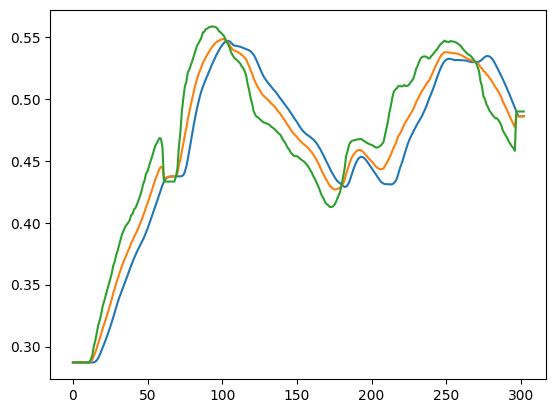

In [7]:
import matplotlib.pyplot as plt

plt.plot(droid_traj_pose[:,0])
plt.plot(droid_traj_actions[:,0])
plt.plot(droid_traj_actions_target[:,0])

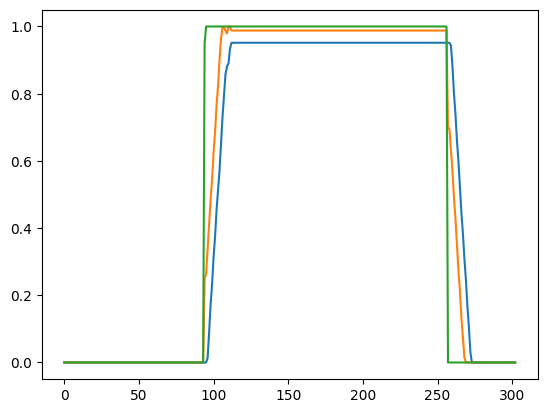

In [8]:
plt.plot(droid_traj_pose_gripper)
plt.plot(droid_traj_actions_gripper)
plt.plot(droid_traj_actions_gripper_target)

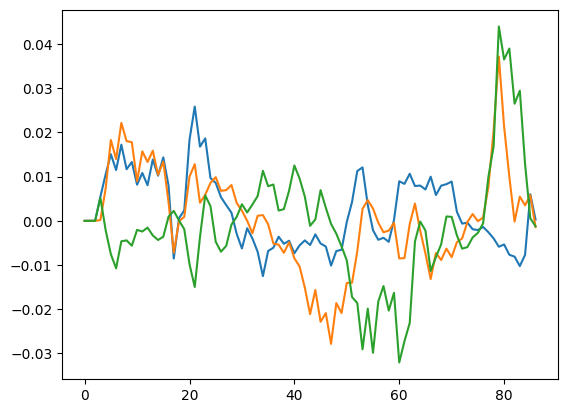

In [9]:
plt.plot(
    np.diff(droid_traj_actions[np.array(indices),:3], axis=0)
)

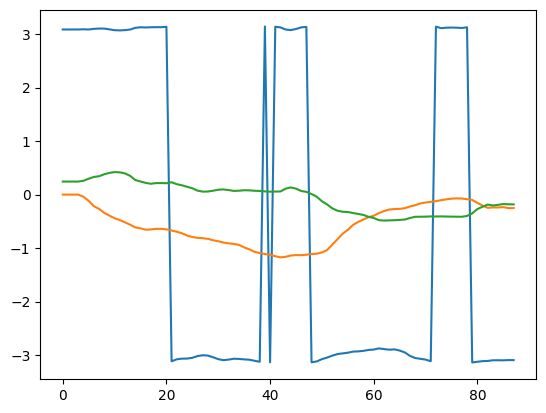

In [10]:
plt.plot(
    droid_traj_actions[np.array(indices),3:6] #3:6
)

# Replay DROID

In [40]:
env = PickPlacePandaEnvController(
    "C:\\Users\\gdev\\Documents\\CS\\DL\\projects\\Robotics\\custom_gym_env\\robots/franka_emika_panda/pick_place_custom.xml",
    render_mode="rgb_array", camera_name='fixed_cam'
)
#env.model.opt.timestep
#1/ (30 * env.model.opt.timestep)
#env.steps_per_frame

#downsample to 4 hz
actions_traj = np.diff(droid_traj_actions[np.array(indices),:3], axis=0)
actions_gripper_traj = np.diff(droid_traj_actions_gripper[np.array(indices)])

#actions_traj = np.concat([actions_traj[[0]], np.zeros(shape=(86, 3))])

obs = env.reset()
env.data.qpos[:7] = droid_traj_qs[0]
mujoco.mj_forward(env.model, env.data)




### compare initial pose
#note that it is valid to compare since
#DROID - extrinsic angles where world frame = base = Mujoco gym env frames

droid_traj_pose[0]

env._get_obs()[0]
env._get_obs()[1] * np.pi / 180

###



obs = (env._get_obs(), 0, False, False, None)
#obs = env.step(np.repeat(0,7))
obs_traj = [obs]

#replay 20 actions
for i in range(len(actions_traj)): #[:20]
    action = np.zeros(7)
    action[:3] = actions_traj[i]
    action[6] = actions_gripper_traj[i]
    #repeat action 5 times for 20 hz control
    target_action = env.delta_to_target(action)
    for _ in range(5):
        obs = env.step(target_action)
    obs_traj.append(obs)

"""
import mujoco.viewer
with mujoco.viewer.launch_passive(env.model, env.data) as viewer:
    
    # 4. Run an empty loop that stays open as long as the window is open
    while viewer.is_running():
        # Keep the UI elements responsive to mouse interaction 
        viewer.sync()
        
        # Idle sleep to prevent your CPU from pinning at 100% usage
        time.sleep(0.01)
"""

array([ 2.87145436e-01,  1.45916818e-02,  4.66360092e-01,  3.08505079e+00,
       -1.39966645e-03,  2.42537065e-01])

array([0.28714545, 0.01459168, 0.46636009])

array([ 3.08505079e+00, -1.39966645e-03,  2.42537061e-01])

'\nimport mujoco.viewer\nwith mujoco.viewer.launch_passive(env.model, env.data) as viewer:\n\n    # 4. Run an empty loop that stays open as long as the window is open\n    while viewer.is_running():\n        # Keep the UI elements responsive to mouse interaction \n        viewer.sync()\n\n        # Idle sleep to prevent your CPU from pinning at 100% usage\n        time.sleep(0.01)\n'

In [34]:
env.control_timestep
env.model.opt.timestep

len(env.frames)

0.05

0.002

202

# Validation

In [35]:
import imageio

writer = imageio.get_writer("imgs_traj_timestep.mp4", format="FFMPEG", fps=30)

for frame in env.frames:
    writer.append_data(frame)

writer.close()

## Position

<Figure size 500x300 with 0 Axes>

Text(0.5, 1.0, 'Replay - Actual 0')

<Figure size 500x300 with 0 Axes>

Text(0.5, 1.0, 'Replay - Actual 1')

<Figure size 500x300 with 0 Axes>

Text(0.5, 1.0, 'Replay - Actual 2')

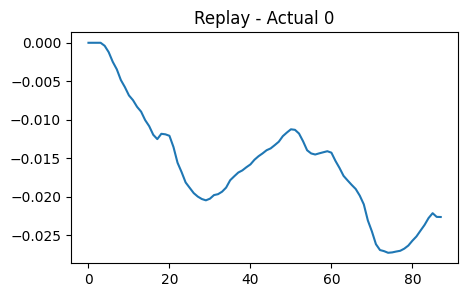

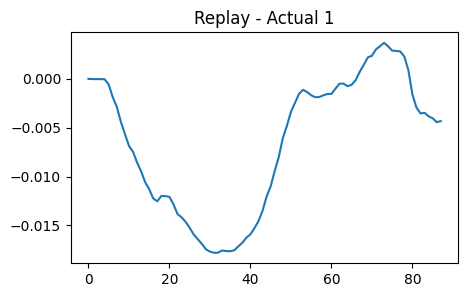

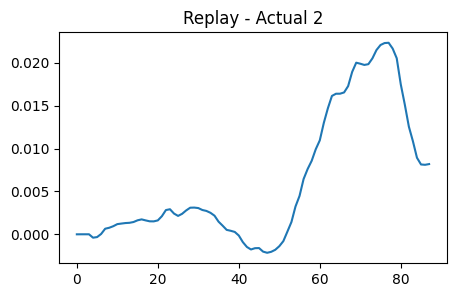

In [84]:
for i in range(3):
    plt.figure(figsize=(5, 3))
    plt.plot(np.stack([o[0][0] for o in obs_traj])[:,i] - droid_traj_actions[np.array(indices)][:,i])
    plt.title(f"Replay - Actual {i}")

<Figure size 500x300 with 0 Axes>

Text(0.5, 1.0, 'Plot 0')

<Figure size 500x300 with 0 Axes>

Text(0.5, 1.0, 'Plot 1')

<Figure size 500x300 with 0 Axes>

Text(0.5, 1.0, 'Plot 2')

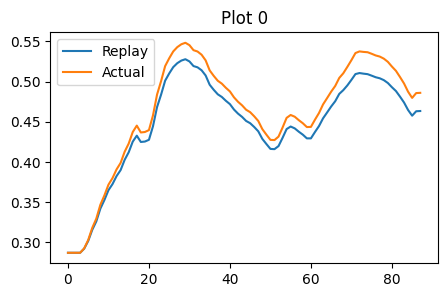

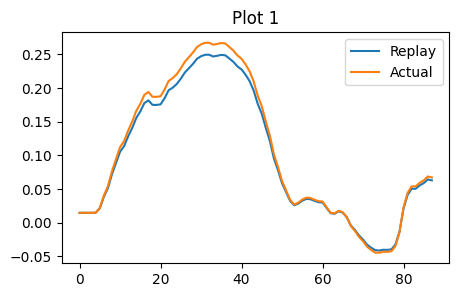

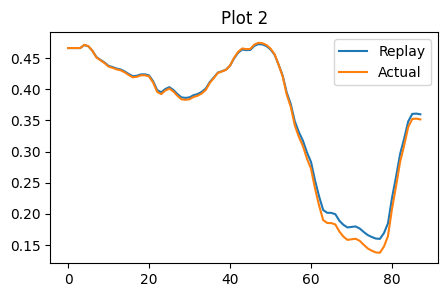

In [41]:
for i in range(3):
    plt.figure(figsize=(5, 3))
    plt.plot(np.stack([o[0][0] for o in obs_traj])[:,i], label="Replay")
    plt.plot(droid_traj_actions[np.array(indices)][:,i], label="Actual") #droid_traj_pose #[:21,i]
    #just for testing stabilizing one pose #plt.plot(np.repeat(droid_traj_pose[np.array(indices)][0,i], len(obs_traj)), label="Series 2")
    plt.title(f"Plot {i}")
    plt.legend()

<Figure size 500x300 with 0 Axes>

Text(0.5, 1.0, 'Plot 0')

<Figure size 500x300 with 0 Axes>

Text(0.5, 1.0, 'Plot 1')

<Figure size 500x300 with 0 Axes>

Text(0.5, 1.0, 'Plot 2')

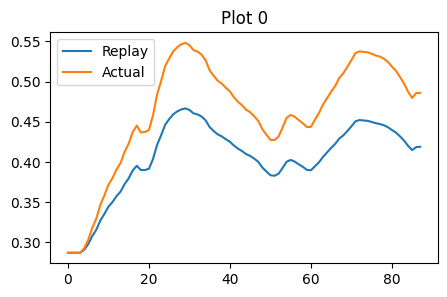

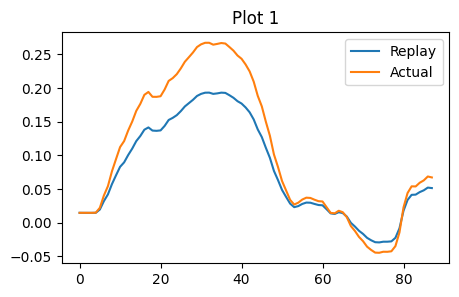

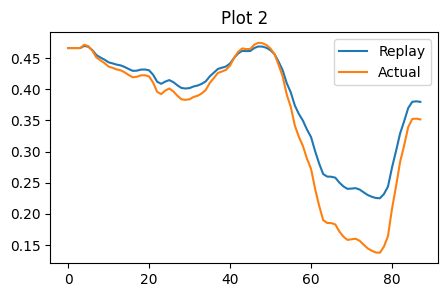

In [35]:
for i in range(3):
    plt.figure(figsize=(5, 3))
    plt.plot(np.stack([o[0][0] for o in obs_traj])[:,i], label="Replay")
    plt.plot(droid_traj_actions[np.array(indices)][:,i], label="Actual") #droid_traj_pose #[:21,i]
    #just for testing stabilizing one pose #plt.plot(np.repeat(droid_traj_pose[np.array(indices)][0,i], len(obs_traj)), label="Series 2")
    plt.title(f"Plot {i}")
    plt.legend()


#obs in sim
#plt.plot(np.stack([o[0][0] for o in obs_traj])[:,0])

#true obs
#plt.plot(droid_traj_pose[np.array(indices)][:21,0])

## Gripper

In [ ]:
len(np.stack([o[0][2] for o in obs_traj]))
len(droid_traj_actions_gripper[np.array(indices)])

np.array([o[0][2] for o in obs_traj]).flatten()
actions_gripper_traj

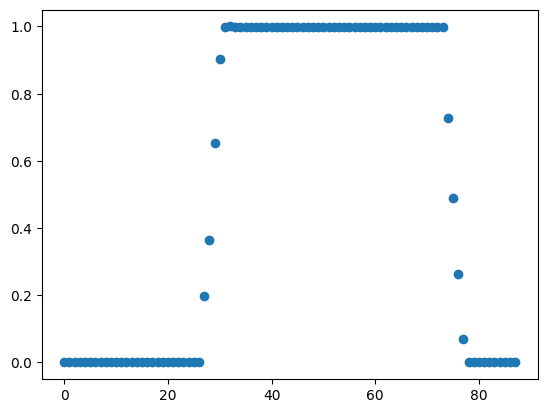

In [18]:
plt.scatter(range(len(np.array(indices))), np.stack([o[0][2] for o in obs_traj]))

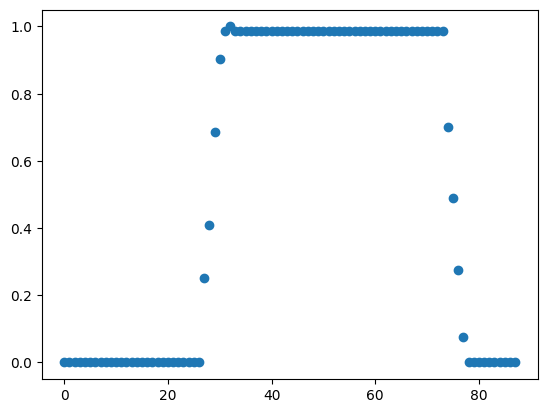

In [19]:
plt.scatter(range(len(np.array(indices))), droid_traj_actions_gripper[np.array(indices)])

## Orientation

<Figure size 500x300 with 0 Axes>

Text(0.5, 1.0, 'Plot 0')

<Figure size 500x300 with 0 Axes>

Text(0.5, 1.0, 'Plot 1')

<Figure size 500x300 with 0 Axes>

Text(0.5, 1.0, 'Plot 2')

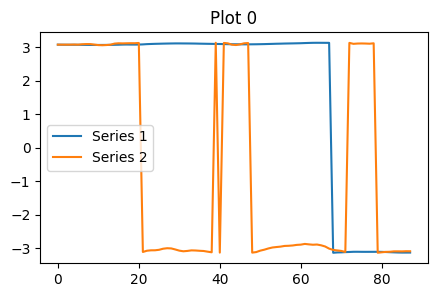

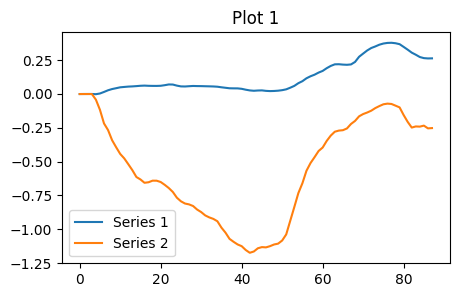

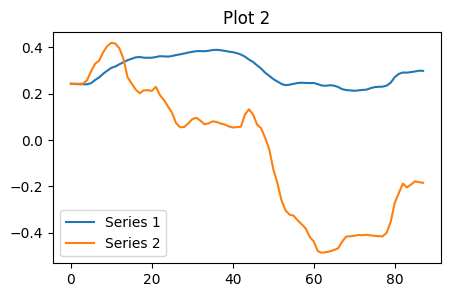

In [42]:
for i in range(0,3):
    plt.figure(figsize=(5, 3))
    plt.plot(np.stack([o[0][1] for o in obs_traj])[:,i] * np.pi / 180, label="Series 1")
    plt.plot(droid_traj_actions[np.array(indices)][:,i+3], label="Series 2") #droid_traj_pose #[:21,i+3]
    #just for testing stabilizing one pose #plt.plot(np.repeat(droid_traj_pose[np.array(indices)][0,i], len(obs_traj)), label="Series 2")
    plt.title(f"Plot {i}")
    plt.legend()

#plt.plot(np.stack([o[0][1] for o in obs_traj]) * np.pi / 180)

# Assessing V-JEPA2 AC performance

In [85]:
with np.load('../outputs/pick_and_place_traj20.npz') as rollout_traj:
    actions_MPC = rollout_traj['arr_0']
    rollout_traj_states = rollout_traj['arr_1']
    actions_MPC.shape
    rollout_traj_states.shape

(7, 7)

(8, 1, 1, 7)

In [86]:
[np.linalg.norm(rollout_traj_states[i][0,0][:3] + actions_MPC[i][:3] - rollout_traj_states[i+1][0,0][:3], 2) for i in range(0,len(actions_MPC))]

[np.float32(0.0049586575),
 np.float32(0.0038609363),
 np.float32(0.0031265114),
 np.float32(0.0019385021),
 np.float32(0.0056490093),
 np.float32(0.0025786005),
 np.float32(0.00137328)]

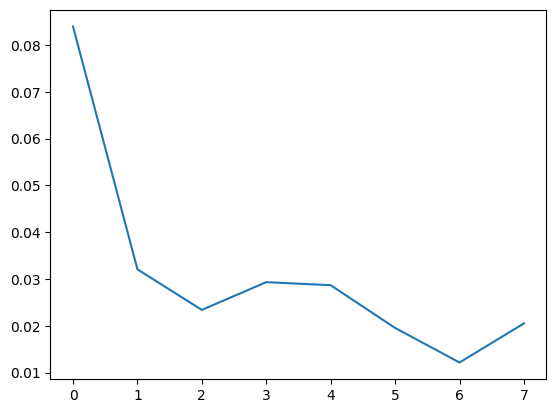

In [80]:
with np.load("../outputs/capture_1769832817.8187528.npz") as traj_grasp:
    plt.plot([np.linalg.norm(traj_grasp['state'][:3] - rollout_traj_states[i][0,0][:3], 2) for i in range(len(rollout_traj_states))])